In [1]:
suppressPackageStartupMessages({
    require(Seurat)
    require(dplyr)
    library(DESeq2)
    require(ggplot2)
    library(RColorBrewer)
})

Warning message:
“package ‘S4Vectors’ was built under R version 4.3.3”
Warning message:
“package ‘IRanges’ was built under R version 4.3.3”
Warning message:
“package ‘Biobase’ was built under R version 4.3.3”


In [2]:
hypomap <- readRDS('mouse_HYPOMAP_scRNASeq.rds')
DefaultAssay(hypomap) <- "RNA"

In [3]:
genes <- read.delim("mouse.gene_name.bg", header = F)$V1
genes <- genes[genes %in% rownames(hypomap)]

In [4]:
Idents(hypomap) <- "C25_named"

cells_to_keep <- c()

# Loop through each cluster
for (cluster in levels(Idents(hypomap))) {
  # Get all cells in this cluster
  cluster_cells <- WhichCells(hypomap, idents = cluster)
  
  # Sample 1000 cells per cluster
  if (length(cluster_cells) > 1000) {
    cluster_cells <- sample(cluster_cells, 1000)
  }
    cells_to_keep <- c(cells_to_keep, cluster_cells)
}

# Subset the Seurat object
hypomap_downsampled <- subset(hypomap, cells = cells_to_keep)

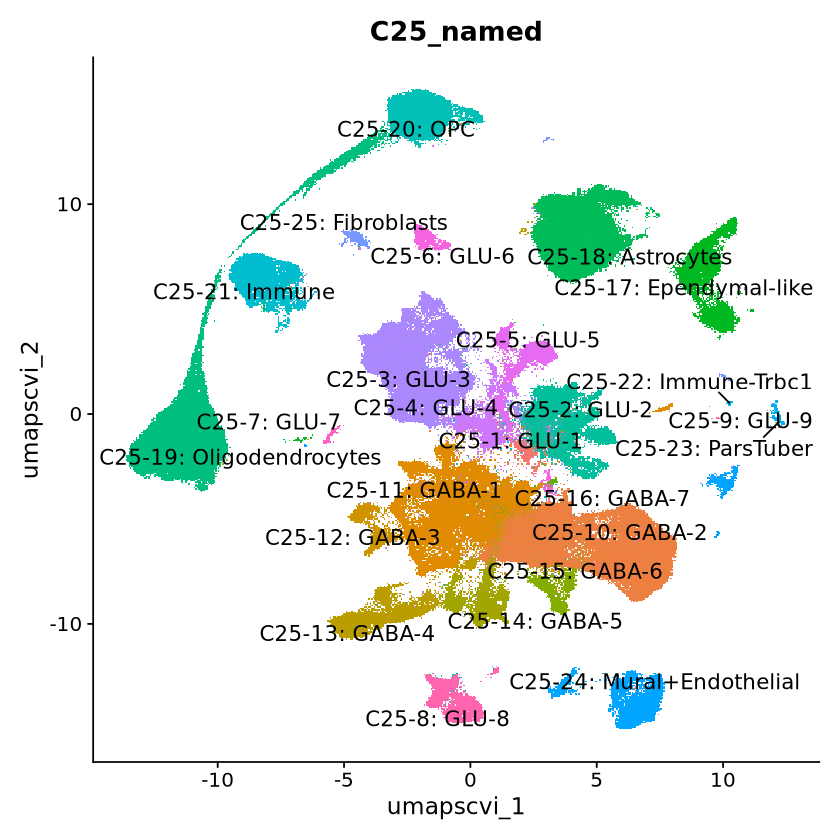

In [5]:
# Make annotated UMAP of mouse hypothalamus
DimPlot(hypomap,group.by = "C25_named",reduction = paste0("umap_scvi"),order = FALSE,
                               label = TRUE,label.size = 4.5,raster = TRUE,pt.size = NULL,repel = TRUE,na.value = bg_col) + NoLegend()

In [6]:
cluster_counts <- as.data.frame(table(Idents(hypomap_downsampled)))
colnames(cluster_counts) <- c("Cluster", "NumCells")
cluster_counts

Cluster,NumCells
<fct>,<int>
C25-1: GLU-1,1000
C25-10: GABA-2,1000
C25-2: GLU-2,1000
C25-11: GABA-1,1000
C25-17: Ependymal-like,1000
C25-18: Astrocytes,1000
C25-3: GLU-3,1000
C25-19: Oligodendrocytes,1000
C25-4: GLU-4,1000


In [7]:
# convert to h5ad


hypomap_downsampled[["RNA"]] <- as(hypomap_downsampled[["RNA"]], "Assay")
sceasy::convertFormat(hypomap_downsampled, main_layer = "count", from="seurat", to="anndata",
                       outFile='Mmus.hypomap_1000per_C25.h5ad')
saveRDS(hypomap_downsampled, file = 'Mmus.hypomap_1000per_C25.rds')